In [10417]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('../')
from utils import * #only needed for xgboost
from friedman1 import *

import warnings
warnings.filterwarnings("ignore") #just to supress warnings

In [10418]:
#Function that returns best params for each pair of (d, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per (target_instances, d), ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col=[0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by=['seed'] + config_cols)

    # aggregate over seeds
    agg = (df.groupby(config_cols, as_index=False)
             .agg(avg_rmse=('rmse', 'mean'),
                  #avg_mae=('val_mae', 'mean'),
                  n_seeds=('seed', 'nunique'),
                  d=('d', 'first')))

    # merge back on config_cols only (minimal fix)
    agg = agg.merge(df, on=config_cols, how='left')

    # sort globally by the fields that determine the ranking
    agg = agg.sort_values(by=['d', 'avg_rmse'], ascending=True)

    # select top-k per (target_instances, d)
    topk_df = agg.groupby(['d'], group_keys=False).head(k)

    # final compact output
    topk_d = topk_df[['d', 'avg_rmse', 'rmse', 'mae']]

    return topk_d, agg




In [10419]:
#Read data (remove v = 0.05 because we chose not to include it)
data_ttb = pd.read_csv('results_200/ttb_LS.csv')
data_ttb = data_ttb[data_ttb['seed'] < 932]

data_xgboost = pd.read_csv('results_200/xgb.csv')
data_xgboost = data_xgboost[data_xgboost['seed'] < 932]

data_xgboost_warmstart = pd.read_csv('results_200/xgb_warmstart.csv')
data_xgboost_warmstart = data_xgboost_warmstart[data_xgboost_warmstart['seed'] < 932]

data_xgboost_pooled = pd.read_csv('results_200/xgb_naive.csv')
data_xgboost_pooled = data_xgboost_pooled[data_xgboost_pooled['seed'] < 932]

#data_two_trada = pd.read_csv('results_200/two_trada.csv')


# Here we make final vizes!

<Axes: xlabel='d', ylabel='rmse'>

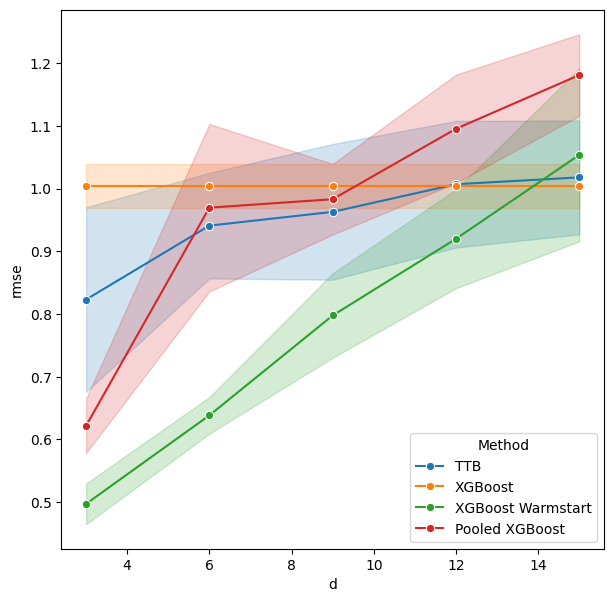

In [10420]:

plt.figure(figsize = (7,7))

import matplotlib as mpl

best_ttb, best_ttb_params = topk_per_d_per_method(
    data_ttb,
    ['d', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=2
)
best_ttb['Method'] = 'TTB'

best_xgboost, best_xgboost_params = topk_per_d_per_method(
    data_xgboost,
    ['d', 'v', 'target_tree_size'], k=2
)
best_xgboost['Method'] = 'XGBoost'

best_xgboost_warmstart, best_xgboost_warmstart_params = topk_per_d_per_method(
    data_xgboost_warmstart,
    ['d', 'v', 'target_tree_size'], k=2
)
best_xgboost_warmstart['Method'] = 'XGBoost Warmstart'

best_xgboost_pooled, best_xgboost_pooled_params = topk_per_d_per_method(
    data_xgboost_pooled,
    ['d', 'v', 'target_tree_size'], k=2
)
best_xgboost_pooled['Method'] = 'Pooled XGBoost'

# best_trada, best_trada_params = topk_per_d_per_method(
#     data_two_trada,
#     ['d', 'lr', 'n_estimators', 'tree_size'], k=10
# )
# best_trada['Method'] = 'TrAdaBoost.R2'


# create new df for viz
df = pd.concat([best_ttb, best_xgboost])
df = pd.concat([df, best_xgboost_warmstart])
df = pd.concat([df, best_xgboost_pooled])
#df = pd.concat([df, best_trada])
sns.lineplot(data=df, x='d', y='rmse', hue='Method', marker = 'o')



In [10421]:
(1.24 + 1.21 + 1.26 + 1.33 + 1.39) / 5

1.286

In [10422]:
best_ttb_params

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,n_seeds,d,Unnamed: 0,seed,method,epochs,val_rmse,val_mae,rmse,mae
102,0.2,3,2,0.01,0.9,0.823155,2,3,50,930,LSTransferTreeBoost,1000,0.676938,0.529350,0.675937,0.536301
103,0.2,3,2,0.01,0.9,0.823155,2,3,410,931,LSTransferTreeBoost,1000,0.948506,0.726255,0.970372,0.748999
126,0.3,2,2,0.01,0.9,0.852821,2,3,62,930,LSTransferTreeBoost,1000,0.710869,0.570500,0.711849,0.552847
127,0.3,2,2,0.01,0.9,0.852821,2,3,422,931,LSTransferTreeBoost,1000,0.917209,0.724867,0.993794,0.796726
142,0.3,3,3,0.01,0.9,0.880780,2,3,70,930,LSTransferTreeBoost,1000,0.755834,0.599658,0.763696,0.607795
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
669,0.2,2,3,0.00,0.5,1.218845,2,15,695,931,LSTransferTreeBoost,1000,1.180034,0.918844,1.244363,0.965268
704,0.3,2,3,0.00,0.5,1.220555,2,15,353,930,LSTransferTreeBoost,1000,1.117721,0.884176,1.139838,0.905894
705,0.3,2,3,0.00,0.5,1.220555,2,15,713,931,LSTransferTreeBoost,1000,1.235796,0.966968,1.301273,1.015833
692,0.3,1,3,0.00,0.5,1.249591,2,15,347,930,LSTransferTreeBoost,1000,1.135209,0.912536,1.188011,0.939768


In [10423]:
best_xgboost_pooled_params

,v,target_tree_size,avg_rmse,n_seeds,d,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae
72,0.175,2.0,0.621782,2,3.0,36,930.0,0.586359,0.462854,0.578347,0.458337
73,0.175,2.0,0.621782,2,3.0,421,931.0,0.663526,0.509628,0.665217,0.522596
44,0.125,2.0,0.633166,2,3.0,22,930.0,0.577888,0.458306,0.576895,0.448933
45,0.125,2.0,0.633166,2,3.0,407,931.0,0.678395,0.526059,0.689437,0.535337
128,0.275,2.0,0.655429,2,3.0,64,930.0,0.666918,0.538783,0.637269,0.515493
...,...,...,...,...,...,...,...,...,...,...,...
631,0.075,1.0,3.395099,2,15.0,700,931.0,4.154708,3.381766,4.146739,3.395041
686,0.175,1.0,3.412091,2,15.0,343,930.0,2.740284,2.207078,2.653242,2.163971
687,0.175,1.0,3.412091,2,15.0,728,931.0,4.210724,3.422601,4.170939,3.406536
658,0.125,1.0,3.451934,2,15.0,329,930.0,2.822836,2.271536,2.738348,2.234165
